In [1]:
import pandas as pd
#Part A
#load the file and get the head, info and describe columns without any cleaning
df = pd.read_csv("Canadian_Health_Survey_Sample.csv")
df.head()
df.info()
df.describe(include='all')
#a quantitative attribute can be income, as because its a measureable amount, and can have averages
#a qualitative attribute can be province, because it can be categorized and put into groups, its unable to be averaged

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 46.6+ KB


,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


In [2]:
#Part B
#standardize gender and smoking by stripping, lowercasing, then mapping to standard names
df ['Gender'] = (df['Gender'].str.strip().str.lower().map({
    'm' : 'Male', 'male' : 'Male', 
    'f': 'Female', 'female': 'Female'
})
                )
df ['Smoking'] = (df['Smoking'].str.strip().str.lower().map({
    'y' : 'Yes', 'yes' : 'Yes', 
    'n' : 'No', 'no' : 'No'
})
                )
#dropna the categories, then enforce data types
df = df.dropna(subset=['BMI','Income','StressLevel','PhysicalActivity'])
df['Age'] = df['Age'].astype(int)
df['Income'] = df['Income'].astype(float)
df['BMI'] = df['BMI'].astype(float)
df['StressLevel'] = df['StressLevel'].astype(int)

#create derived columns for bmi and income brackets
def BMI_Category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'
df['BMI_Category'] = df['BMI'].apply(BMI_Category)
def IncomeBracket(income):
    if income < 50000:
        return '<50k'
    elif income < 80000:
        return '50-80k'
    elif income < 110000:
        return '80-110k'
    else:
        return '>110k'
#apply categories and visualize
df['IncomeBracket'] = df['Income'].apply(IncomeBracket)
df[['BMI', 'BMI_Category', 'Income', 'IncomeBracket']].head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 734 entries, 0 to 848
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          734 non-null    object 
 1   Gender            734 non-null    object 
 2   Age               734 non-null    int32  
 3   Income            734 non-null    float64
 4   BMI               734 non-null    float64
 5   PhysicalActivity  734 non-null    float64
 6   Smoking           734 non-null    object 
 7   SelfRatedHealth   734 non-null    object 
 8   StressLevel       734 non-null    int32  
 9   BMI_Category      734 non-null    object 
 10  IncomeBracket     734 non-null    object 
dtypes: float64(3), int32(2), object(6)
memory usage: 45.9+ KB


,Age,Income,BMI,PhysicalActivity,StressLevel
count,734.000000,734.000000,734.000000,734.000000,734.000000
mean,49.331063,77400.644414,27.507493,3.481880,5.303815
std,18.304703,22799.387713,5.063788,1.943832,2.134383
min,18.000000,5000.000000,13.500000,0.000000,1.000000
25%,33.000000,63541.000000,24.100000,2.000000,4.000000
50%,49.000000,78251.000000,27.400000,3.400000,5.000000
75%,66.000000,90298.000000,30.900000,4.700000,7.000000
max,80.000000,250000.000000,60.000000,10.400000,10.000000


In [3]:
df.head(10)
#cleaned csv

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel,BMI_Category,IncomeBracket
0,Ontario,Female,59,80572.0,25.7,3.8,Yes,Good,6,Overweight,80-110k
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9,Normal,>110k
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10,Overweight,50-80k
4,Saskatchewan,Female,79,113966.0,31.2,1.6,No,Fair,6,Obese,>110k
5,Newfoundland and Labrador,Female,24,101828.0,27.8,4.5,Yes,Good,5,Overweight,80-110k
6,Ontario,Female,68,64076.0,24.3,0.9,Yes,Very Good,3,Normal,50-80k
7,Nova Scotia,Female,72,82479.0,27.3,3.6,No,Very Good,8,Overweight,80-110k
8,British Columbia,Female,19,78040.0,34.4,2.9,Yes,Good,4,Obese,50-80k
9,Ontario,Male,55,83639.0,30.0,4.1,No,Very Good,4,Obese,80-110k
10,Manitoba,Male,54,64026.0,18.6,3.7,No,Fair,8,Normal,50-80k


In [4]:
df['Gender'].value_counts(dropna=False)

Gender
Male      385
Female    349
Name: count, dtype: int64

In [5]:
df['Smoking'].value_counts(dropna=False) #interesting that we can see that there are far more non smokers than smokers in Canada, the percentage is that ~77% of people do NOT smoke

Smoking
No     570
Yes    164
Name: count, dtype: int64

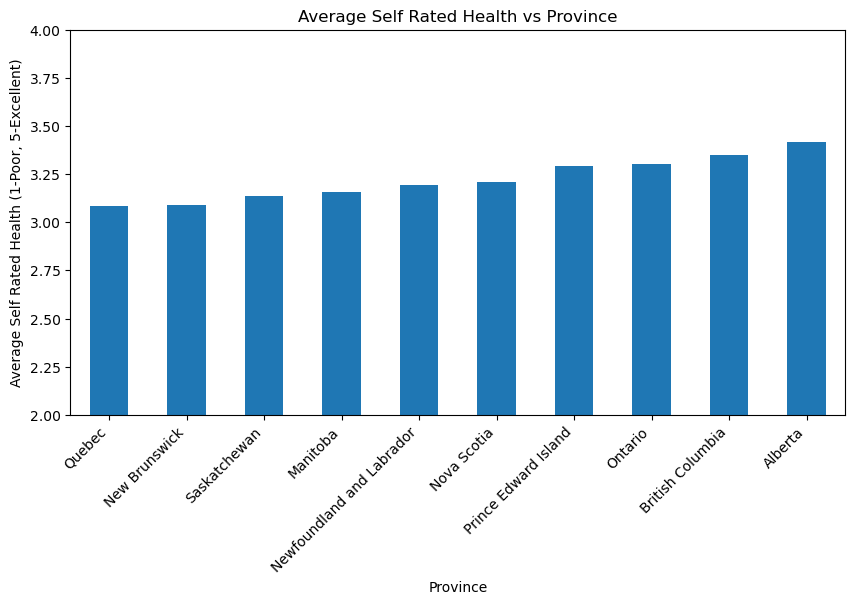

In [6]:
#Part C
import matplotlib.pyplot as plt
#create the health map and map it to the column
health_map = {'Poor': 1, 'Fair' : 2, 'Good' : 3, 'Very Good' : 4, 'Excellent' : 5}
df['SelfRatedHealth_num'] = df['SelfRatedHealth'].map(health_map)

#create a simple bar graph, design choices would include the ylim function
#changing the ylim to 2,4 makes it so the bars arent at the top of the screen
#it also allows you to see the subtle differents slightly better
#then also we have the xticks rotation and pivot point, this just allows the labels to be under the bars better
#it makes them more readable without having to move your head sideways
province_mean = (df.groupby('Province')['SelfRatedHealth_num'].mean().sort_values())
plt.figure(figsize=(10,5))
province_mean.plot(kind='bar')
plt.ylim(2,4)
plt.xlabel('Province')
plt.ylabel('Average Self Rated Health (1-Poor, 5-Excellent)')
plt.title('Average Self Rated Health vs Province')
plt.xticks(rotation=45, ha='right')
plt.show()

In [7]:
#for the above graph, nothing particualrly interesting, just that Quebec has the lowest health and Alberta the highest

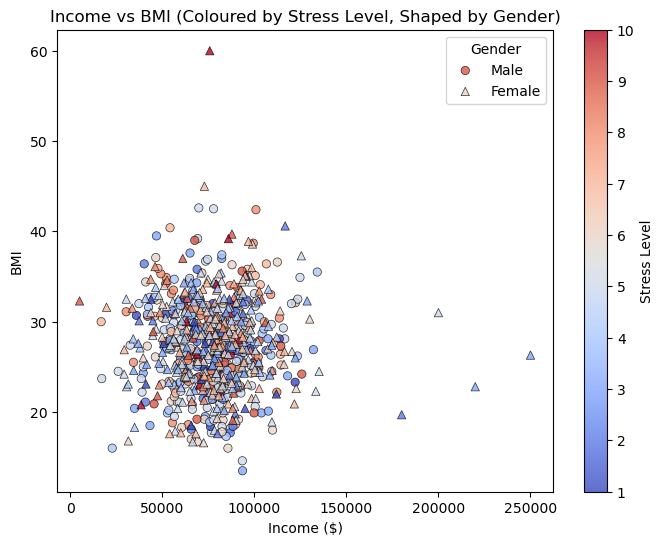

In [8]:
plt.figure(figsize=(8, 6))


# scatter plot, we use o and ^ to mark male and female points, which are easily distiguishable
# we use the cmap of coolwarm to easily see the stress level (warmer = more stressed)
# we also use edgecolors and linewidth to make it easier to see the plot points
# transparency is at 0.8 so you can see the points in the middle
# but it also allows the outliers to be visible without too much fading at lower stress levels
markers = {'Male': 'o', 'Female': '^'}

for gender, marker in markers.items():
    subset = df[df['Gender'] == gender]
    plt.scatter(
        subset['Income'],
        subset['BMI'],
        c=subset['StressLevel'],
        cmap = 'coolwarm',
        marker=marker,
        alpha=0.8, #transparency
        label=gender, #legend
        edgecolors = 'black',
        linewidth = 0.5
    )

cbar = plt.colorbar()
cbar.set_label('Stress Level')

plt.xlabel('Income ($)')
plt.ylabel('BMI')
plt.title('Income vs BMI (Coloured by Stress Level, Shaped by Gender)')
plt.legend(title='Gender')
plt.show()

In [9]:
#from this graphg we can see that there really is not a strong correlation between BMI income, and stress level
# there are people by the bottom of the graph we can see that there are many people with low income yet also low stress
# then possibly a slight correlation with higher BMI and higher stress, which is likely due to phyical stress on the heart from high levels of body fight
# then any outlier we see on the income, are all lower stress level, so maybe money can buy happiness

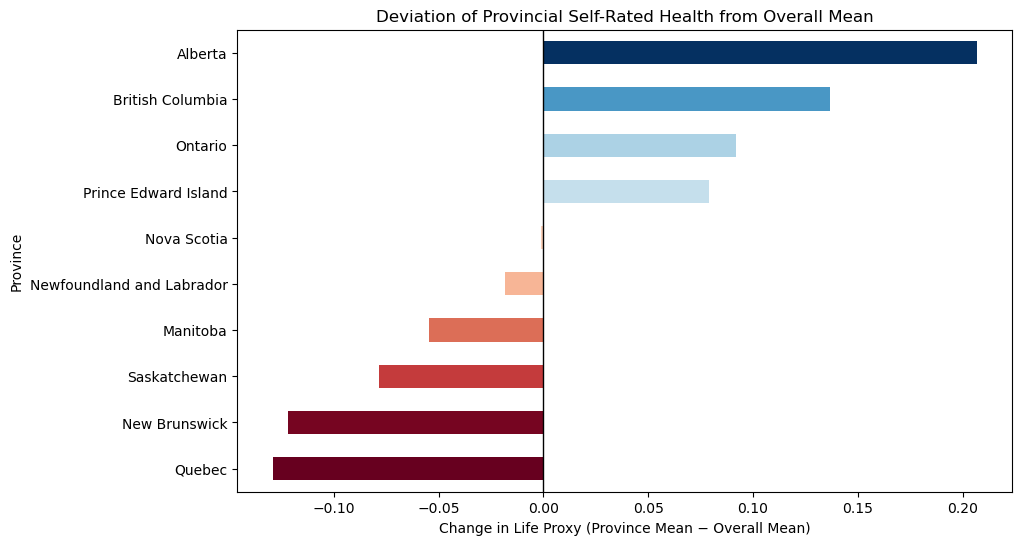

In [10]:


#horizontal bar graph, using a red blue colourmap to show a negative/positive delta life proxy for provinces
#blue for higher than average and red for below
#it makes it easy to understand that negative is bad and blue is good
#there is the line in the middle so it is easy to see the mean and which provinces are above and below
overall_mean = df['SelfRatedHealth_num'].mean()
lifeProxy = (df.groupby('Province')['SelfRatedHealth_num'].mean().subtract(overall_mean).sort_values())
plt.figure(figsize=(10, 6))

cmap = plt.get_cmap('RdBu')
norm = plt.Normalize(vmin=lifeProxy.min(), vmax=lifeProxy.max())
colors = cmap(norm(lifeProxy.values))

lifeProxy.plot(
    kind='barh',
    color = colors,
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Change in Life Proxy (Province Mean − Overall Mean)')
plt.ylabel('Province')
plt.title('Deviation of Provincial Self-Rated Health from Overall Mean')
plt.show()


In [11]:
#this is showing essentially the same data from the first chart, that Alberta is healthy and Quebec less.

In [12]:
#One potential limitation could be that not all the parts on Canada are on here, such as Nunavut, Yukon or Northwest Territories
#we know that the population is low in those areas, but it would still be interesting to know that information
#I also notice that there are very few outlier in the income column, It doesn't make sense that there are that little people making 150k+
#there are around 100 people who did not answer the smoking question, possibly because they are occasional smokers, so could not say yes or no particularly
#I would like if there was another section on smoking frequency, it would be interesting to see the average amount a smoker actually smokes.